### Real Estate Investment Recommender

This notebook provides a framework for building a real estate investment recommender. It covers data loading, preprocessing, and outlines where recommendation logic would be implemented.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

#### 1. Data Loading

We'll start by loading real estate data. For demonstration purposes, we'll create a synthetic dataset. In a real-world scenario, you would load data from a CSV, a database, or an API.

In [ ]:
import pandas as pd
import numpy as np # Need numpy for synthetic data generation

# Load data from data.csv
try:
    df = pd.read_csv('data.csv')
    print("Data loaded successfully from data.csv")

    # Standardize column names if they exist and aren't already renamed
    if 'beds' in df.columns and 'bedrooms' not in df.columns:
        df = df.rename(columns={'beds': 'bedrooms'})
    if 'baths' in df.columns and 'bathrooms' not in df.columns:
        df = df.rename(columns={'baths': 'bathrooms'})
    if 'type' in df.columns and 'property_type' not in df.columns:
        df = df.rename(columns={'type': 'property_type'})
    # Use 'city' as 'location' if 'location' is missing, otherwise try 'neighborhood'
    if 'location' not in df.columns:
        if 'city' in df.columns:
            df = df.rename(columns={'city': 'location'})
        elif 'neighborhood' in df.columns:
            df = df.rename(columns={'neighborhood': 'location'})

    # Try to convert 'size' to 'square_footage' or generate synthetically
    if 'size' in df.columns and 'square_footage' not in df.columns:
        # Attempt to extract numerical part from 'size' (e.g., '1,200 sq ft' -> '1200')
        df['square_footage'] = pd.to_numeric(df['size'].astype(str).str.replace(r'[^0-9.]', '', regex=True), errors='coerce')
        # Fill NaN from conversion with synthetic data
        nan_sq_ft_count = df['square_footage'].isnull().sum()
        if nan_sq_ft_count > 0:
            print(f"Warning: {nan_sq_ft_count} non-numeric values in 'size' column. Generating synthetic 'square_footage' for missing values.")
            df.loc[df['square_footage'].isnull(), 'square_footage'] = np.random.randint(800, 3000, nan_sq_ft_count)
        df['square_footage'] = df['square_footage'].astype(int)
    elif 'square_footage' not in df.columns: # If 'size' column doesn't exist either
        print("Generating synthetic 'square_footage' column.")
        df['square_footage'] = np.random.randint(800, 3000, len(df))

    # Generate missing investment-specific columns if they don't exist
    if 'property_id' not in df.columns:
        print("Generating synthetic 'property_id' column.")
        df['property_id'] = range(1, len(df) + 1)
    if 'year_built' not in df.columns:
        print("Generating synthetic 'year_built' column.")
        df['year_built'] = np.random.randint(1980, 2023, len(df))
    if 'rental_income_potential' not in df.columns:
        print("Generating synthetic 'rental_income_potential' column.")
        # Make rental income somewhat proportional to price if available, otherwise random
        if 'price' in df.columns:
            df['rental_income_potential'] = (df['price'] * np.random.uniform(0.001, 0.005, len(df))).astype(int) + np.random.randint(500, 2000, len(df))
            df['rental_income_potential'] = df['rental_income_potential'].clip(lower=1000) # Ensure a minimum
        else:
            df['rental_income_potential'] = np.random.randint(1000, 5000, len(df))
    if 'property_tax_rate' not in df.columns:
        print("Generating synthetic 'property_tax_rate' column.")
        df['property_tax_rate'] = np.random.uniform(0.005, 0.02, len(df)).round(4)
    if 'vacancy_rate' not in df.columns:
        print("Generating synthetic 'vacancy_rate' column.")
        df['vacancy_rate'] = np.random.uniform(0.01, 0.1, len(df)).round(3)
    if 'cap_rate' not in df.columns:
        print("Generating synthetic 'cap_rate' column.")
        # If rental_income_potential and price are generated/present, calculate cap_rate
        if 'rental_income_potential' in df.columns and 'price' in df.columns:
            df['cap_rate'] = ((df['rental_income_potential'] * 12) / df['price']).clip(0.03, 0.08).round(3)
        else:
            df['cap_rate'] = np.random.uniform(0.03, 0.08, len(df)).round(3)
    if 'amenities_score' not in df.columns:
        print("Generating synthetic 'amenities_score' column.")
        df['amenities_score'] = np.random.randint(1, 10, len(df))

except FileNotFoundError:
    print("Error: data.csv not found. Please upload the file or check the path.")
    # Fallback to full synthetic data if file not found
    print("Generating full synthetic data for demonstration...")
    data = {
        'property_id': range(1, 21),
        'location': np.random.choice(['Downtown', 'Suburban Area', 'Rural Area', 'Coastal'], 20),
        'property_type': np.random.choice(['Apartment', 'House', 'Condo', 'Townhouse'], 20),
        'bedrooms': np.random.randint(1, 5, 20),
        'bathrooms': np.random.randint(1, 4, 20),
        'square_footage': np.random.randint(800, 3000, 20),
        'price': np.random.randint(150000, 1000000, 20),
        'year_built': np.random.randint(1980, 2023, 20),
        'rental_income_potential': np.random.randint(1000, 5000, 20),
        'property_tax_rate': np.random.uniform(0.005, 0.02, 20).round(4),
        'vacancy_rate': np.random.uniform(0.01, 0.1, 20).round(3),
        'cap_rate': np.random.uniform(0.03, 0.08, 20).round(3),
        'amenities_score': np.random.randint(1, 10, 20)
    }
    df = pd.DataFrame(data)

print("First 5 rows of the dataset:")
display(df.head())

Data loaded successfully from data.csv
Generating synthetic 'property_id' column.
Generating synthetic 'year_built' column.
Generating synthetic 'rental_income_potential' column.
Generating synthetic 'property_tax_rate' column.
Generating synthetic 'vacancy_rate' column.
Generating synthetic 'cap_rate' column.
Generating synthetic 'amenities_score' column.
First 5 rows of the dataset:


,url,bedrooms,location,date,size,property_type,bathrooms,price,neighborhood,square_footage,property_id,year_built,rental_income_potential,property_tax_rate,vacancy_rate,cap_rate,amenities_score
0,https://www.99acres.com/residential-land-plot-...,0,Bangalore,2025-02-19,799-1258 sqft,Residential land / Plot,0,2317000.0,Jigani,7991258,1,1997,8954,0.0108,0.032,0.046,9
1,https://www.99acres.com/2-bhk-bedroom-apartmen...,2,Bangalore,2025-02-19,1085 sqft,2 BHK Flat,2,12500000.0,Tumkur Road,1085,2,1997,44775,0.0100,0.043,0.043,2
2,https://www.99acres.com/sumadhura-capitol-resi...,3,Bangalore,2025-02-19,1525-2150 sqft,"3, 4 BHK Apartment",0,23200000.0,Whitefield,15252150,3,1983,87455,0.0141,0.036,0.045,3
3,https://www.99acres.com/provident-botanico-sou...,2,Bangalore,2025-02-19,658-1003 sqft,"2, 3 BHK Apartment",0,889000.0,Soukya Road,6581003,4,1997,4947,0.0168,0.011,0.067,2
4,https://www.99acres.com/kvg-superior-kalkere-b...,2,Bangalore,2025-02-19,1179-1449 sqft,"2, 3 BHK Apartment",0,6483000.0,Kalkere,11791449,5,2002,23578,0.0190,0.062,0.044,1


#### 2. Data Preprocessing

This section involves cleaning the data, handling missing values, and feature engineering if necessary. For our synthetic data, basic checks will suffice.

In [ ]:
print("Dataset Information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 287 entries, 0 to 286
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   url                      287 non-null    object 
 1   bedrooms                 287 non-null    int64  
 2   location                 287 non-null    object 
 3   date                     287 non-null    object 
 4   size                     287 non-null    object 
 5   property_type            287 non-null    object 
 6   bathrooms                287 non-null    int64  
 7   price                    287 non-null    float64
 8   neighborhood             287 non-null    object 
 9   square_footage           287 non-null    int64  
 10  property_id              287 non-null    int64  
 11  year_built               287 non-null    int64  
 12  rental_income_potential  287 non-null    int64  
 13  property_tax_rate        287 non-null    float64
 14  vacan

Since our synthetic data has no missing values, we'll proceed to feature engineering. We can calculate some common investment metrics.

In [ ]:
# Calculate Gross Rental Yield (Annual Rental Income / Property Price)
df['gross_rental_yield'] = (df['rental_income_potential'] * 12) / df['price']

# Calculate Net Operating Income (NOI) - simplified for this example
# NOI = Gross Rental Income - Operating Expenses (assume property tax as major expense here)
df['noi'] = (df['rental_income_potential'] * 12) - (df['price'] * df['property_tax_rate'])

# Calculate Cash-on-Cash Return (simplified: NOI / Property Price)
df['cash_on_cash_return'] = df['noi'] / df['price']

display(df.head())

,url,bedrooms,location,date,size,property_type,bathrooms,price,neighborhood,square_footage,property_id,year_built,rental_income_potential,property_tax_rate,vacancy_rate,cap_rate,amenities_score,gross_rental_yield,noi,cash_on_cash_return
0,https://www.99acres.com/residential-land-plot-...,0,Bangalore,2025-02-19,799-1258 sqft,Residential land / Plot,0,2317000.0,Jigani,7991258,1,1997,8954,0.0108,0.032,0.046,9,0.046374,82424.4,0.035574
1,https://www.99acres.com/2-bhk-bedroom-apartmen...,2,Bangalore,2025-02-19,1085 sqft,2 BHK Flat,2,12500000.0,Tumkur Road,1085,2,1997,44775,0.0100,0.043,0.043,2,0.042984,412300.0,0.032984
2,https://www.99acres.com/sumadhura-capitol-resi...,3,Bangalore,2025-02-19,1525-2150 sqft,"3, 4 BHK Apartment",0,23200000.0,Whitefield,15252150,3,1983,87455,0.0141,0.036,0.045,3,0.045235,722340.0,0.031135
3,https://www.99acres.com/provident-botanico-sou...,2,Bangalore,2025-02-19,658-1003 sqft,"2, 3 BHK Apartment",0,889000.0,Soukya Road,6581003,4,1997,4947,0.0168,0.011,0.067,2,0.066776,44428.8,0.049976
4,https://www.99acres.com/kvg-superior-kalkere-b...,2,Bangalore,2025-02-19,1179-1449 sqft,"2, 3 BHK Apartment",0,6483000.0,Kalkere,11791449,5,2002,23578,0.0190,0.062,0.044,1,0.043643,159759.0,0.024643


#### 3. Exploratory Data Analysis (EDA)

Understanding the distributions and relationships within our data.

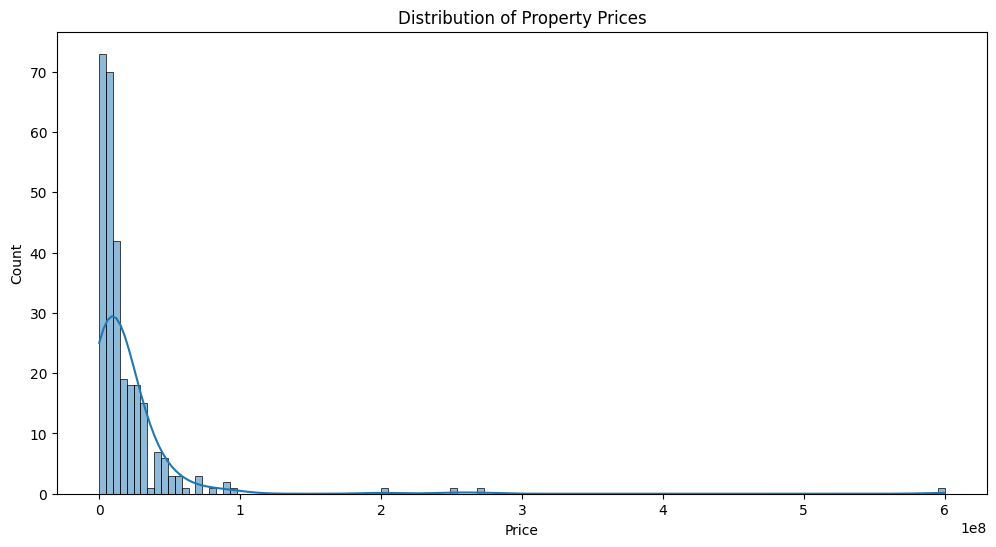

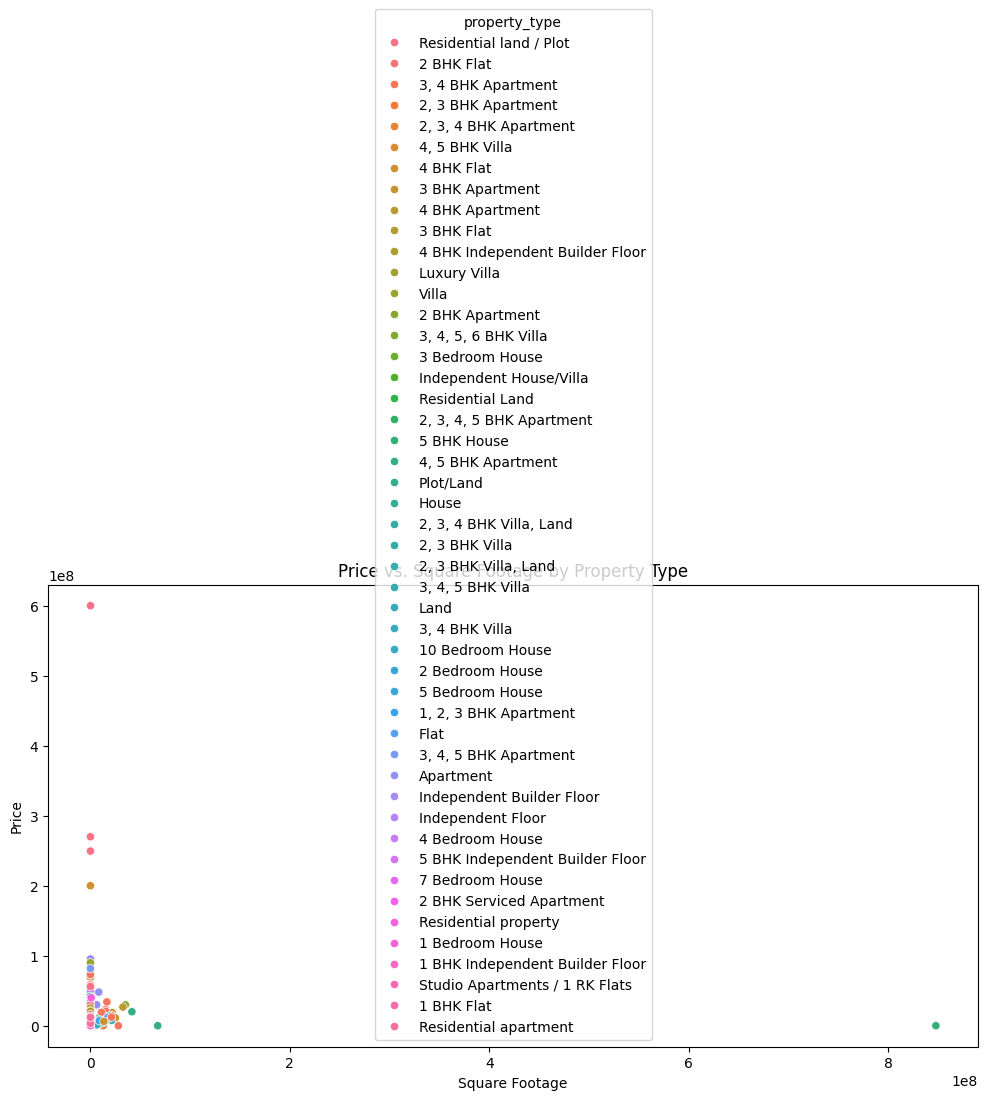

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(df['price'], kde=True)
plt.title('Distribution of Property Prices')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(12, 6))
sns.scatterplot(x='square_footage', y='price', data=df, hue='property_type')
plt.title('Price vs. Square Footage by Property Type')
plt.xlabel('Square Footage')
plt.ylabel('Price')
plt.show()

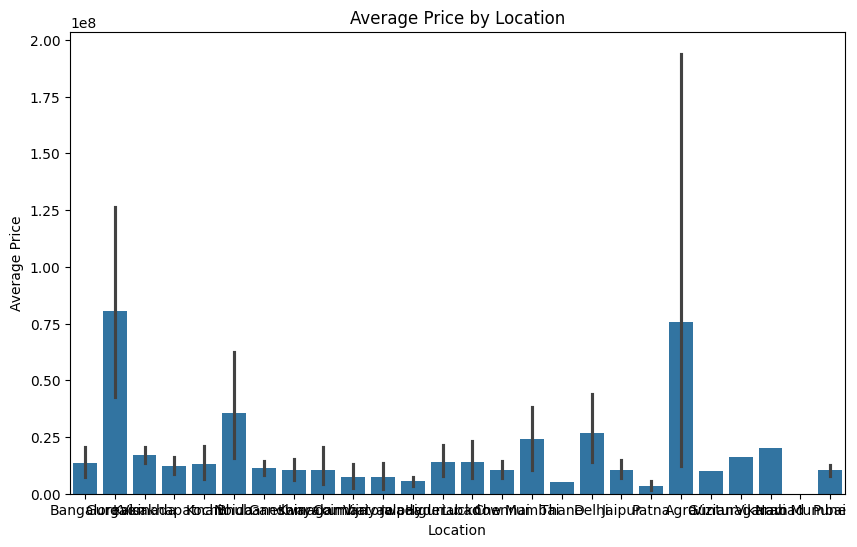

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='location', y='price', data=df, estimator=np.mean)
plt.title('Average Price by Location')
plt.xlabel('Location')
plt.ylabel('Average Price')
plt.show()

#### 4. Recommendation Logic

This is where you would implement the core of your recommender. This could be rule-based, score-based, or use machine learning models.

**Example: Rule-Based Recommendation**

We can define criteria for a 'good' investment, such as:
- High Cap Rate
- High Gross Rental Yield
- Low Vacancy Rate
- Specific location or property type preferences

In [ ]:
def recommend_properties_rule_based(df, min_cap_rate=0.05, min_rental_yield=0.07, max_price=500000, preferred_location=None):
    recommendations = df[
        (df['cap_rate'] >= min_cap_rate) &
        (df['gross_rental_yield'] >= min_rental_yield) &
        (df['price'] <= max_price)
    ]

    if preferred_location:
        recommendations = recommendations[recommendations['location'] == preferred_location]

    # Sort by a combination of metrics, e.g., cap rate and rental yield
    recommendations = recommendations.sort_values(by=['cap_rate', 'gross_rental_yield'], ascending=[False, False])

    return recommendations

# Get recommendations based on some criteria
recommended_properties = recommend_properties_rule_based(
    df,
    min_cap_rate=0.04,
    min_rental_yield=0.06,
    max_price=700000,
    preferred_location='Suburban Area'
)

print("Recommended Properties (Top 5):")
display(recommended_properties.head())

Recommended Properties (Top 5):


,url,bedrooms,location,date,size,property_type,bathrooms,price,neighborhood,square_footage,property_id,year_built,rental_income_potential,property_tax_rate,vacancy_rate,cap_rate,amenities_score,gross_rental_yield,noi,cash_on_cash_return


#### Further Enhancements (Ideas):

- **User Preferences**: Allow users to input their specific criteria (e.g., desired number of bedrooms, target ROI).
- **Machine Learning**: Use supervised learning (e.g., regression to predict future appreciation) or unsupervised learning (e.g., clustering to find similar properties).
- **Advanced Metrics**: Incorporate more complex financial calculations like IRR, NPV.
- **External Data**: Integrate neighborhood crime rates, school ratings, economic growth data.
- **Weighted Scoring**: Assign weights to different features based on their importance to the investor.
- **Time Series Analysis**: If historical data is available, analyze trends in property values and rental incomes.

DATASET LINK:
https://drive.google.com/file/d/1gznMowg5dO0FOImH79GspakLjUFrJgay/view?usp=sharing